In [1]:
##### Builds tables to show representativeness of final training data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import matplotlib.cm as cm

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import model data
capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor.csv")

# Import country data
country_info = pd.read_csv(f'{cd}/Data/Correspondence_tables/country_names.csv', encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/training_data_stats"

In [3]:
### Add country_info to model data

# pull country codes
capital_model['ISO3'] = capital_model['PROJ_ID'].str[:3]
labor_model['ISO3'] = labor_model['PROJ_ID'].str[:3]

# merge on country codes
capital_model = capital_model.merge(country_info, on='ISO3', how='left')
labor_model = labor_model.merge(country_info, on='ISO3', how='left')

In [4]:
### Get unique list of groups 

# region 
UN_regions = pd.DataFrame(country_info['UN_region'].unique(), columns=['UN_region'])
WB_income = pd.DataFrame(country_info['income_group'].unique(), columns=['income_group'])

WB_income = WB_income.dropna()

In [5]:
#### Calculate stats 

# total number of observations
capital_total = len(capital_model)
labor_total = len(labor_model)

# total by country
capital_country = capital_model.groupby('Country_Name').size().reset_index(name='count_capital')
labor_country = labor_model.groupby('Country_Name').size().reset_index(name='count_labor')

capital_country['share_capital'] = ((capital_country['count_capital'] / capital_total) * 100).round(2)
labor_country['share_labor'] = ((labor_country['count_labor'] / labor_total) * 100).round(2)

# total by region
capital_region = capital_model.groupby('UN_region').size().reset_index(name='count_capital')
labor_region = labor_model.groupby('UN_region').size().reset_index(name='count_labor')

capital_region = capital_region.merge(UN_regions, on='UN_region', how='outer')
labor_region = labor_region.merge(UN_regions, on='UN_region', how='outer')

capital_region = capital_region.fillna(0)
labor_region = labor_region.fillna(0)

capital_region['share_capital'] = ((capital_region['count_capital'] / capital_total) * 100).round(2)
labor_region['share_labor'] = ((labor_region['count_labor'] / labor_total) * 100).round(2)

# total by income group
capital_income = capital_model.groupby('income_group').size().reset_index(name='count_capital')
labor_income = labor_model.groupby('income_group').size().reset_index(name='count_labor')

capital_income = capital_income.merge(WB_income, on='income_group', how='outer')
labor_income = labor_income.merge(WB_income, on='income_group', how='outer')

capital_income = capital_income.fillna(0)
labor_income = labor_income.fillna(0)

capital_income['share_capital'] = ((capital_income['count_capital'] / capital_total) * 100).round(2)
labor_income['share_labor'] = ((labor_income['count_labor'] / labor_total) * 100).round(2)

In [6]:
### Merge into 1 df for each stat

region = capital_region.merge(labor_region, on='UN_region', how='outer')
income = capital_income.merge(labor_income, on='income_group', how='outer')

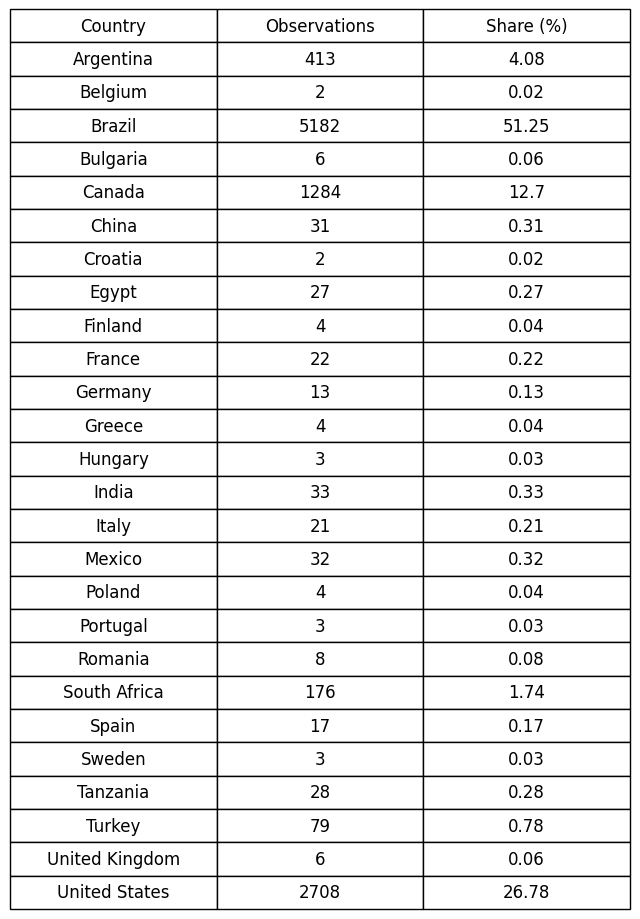

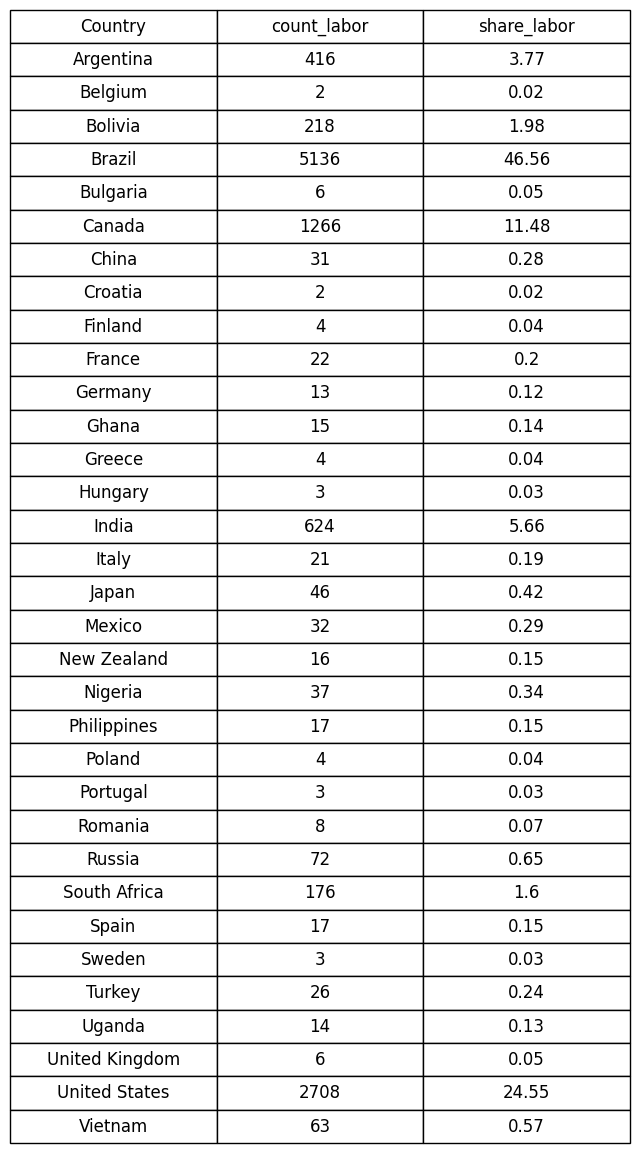

In [7]:
### Make country tables

capital_country = capital_country.rename(columns={
    'Country_Name': 'Country',
    'count_capital': 'Observations',
    'share_capital': 'Share (%)'
})

labor_country = labor_country.rename(columns={
    'Country_Name': 'Country',
    'count_capital': 'Observations',
    'share_capital': 'Share (%)'
})

### Create fig (capital))
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=capital_country.values,
    colLabels=capital_country.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/capital_country_table.png", dpi=300, bbox_inches='tight')


### Create fig (labor))
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=labor_country.values,
    colLabels=labor_country.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/labor_country_table.png", dpi=300, bbox_inches='tight')

In [8]:
region.columns

Index(['UN_region', 'count_capital', 'share_capital', 'count_labor',
       'share_labor'],
      dtype='object')

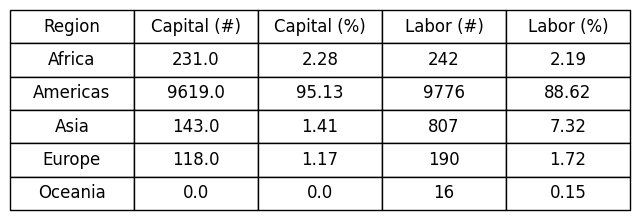

In [9]:
### Make region table

region = region.rename(columns={
    'UN_region': 'Region',
    'count_capital': 'Capital (#)',
    'share_capital': 'Capital (%)', 
    'count_labor': 'Labor (#)',
    'share_labor': 'Labor (%)'
})

### Create fig (capital))
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=region.values,
    colLabels=region.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/region_table.png", dpi=300, bbox_inches='tight')

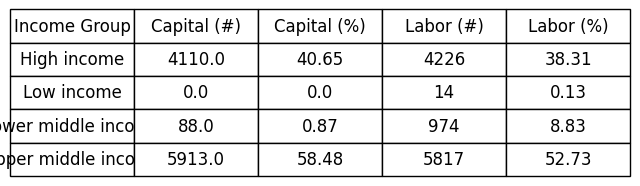

In [10]:
### Make region table

income = income.rename(columns={
    'income_group': 'Income Group',
    'count_capital': 'Capital (#)',
    'share_capital': 'Capital (%)', 
    'count_labor': 'Labor (#)',
    'share_labor': 'Labor (%)'
})

### Create fig (capital))
fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=income.values,
    colLabels=income.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.show()

fig.savefig(f"{fd}/income_table.png", dpi=300, bbox_inches='tight')